# STEP 09 — Learned Policy Analysis & Interpretation

A végső notebook kérdése nem az, hogy „mennyi lett a score?”, hanem az, hogy **mit tanult meg az agent**, és ez energetikai szempontból értelmes-e. A policy interpretáció különösen fontos RL-nél, mert egy látszólag jó aggregált reward mögött is lehet furcsa vagy veszélyes viselkedés.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


In [2]:
from battery_rl.agents.q_learning import TabularQLearningAgent, train_q_learning
from battery_rl.evaluation import evaluate_policy
from workflow.step05_q_learning import make_agent

q_path = MODEL_DIR / "q_learning_agent.pkl"
if q_path.exists():
    agent = TabularQLearningAgent.load(q_path)
else:
    agent = make_agent(cfg, 42)
    train_q_learning(build_env(train, cfg), agent, 150 if QUICK_MODE else 600, seed=42)
    agent.save(q_path)
metrics, logs = evaluate_policy(lambda: build_env(test, cfg, random_start=True), agent, seeds=SEEDS, episodes=10 if QUICK_MODE else 30)
print("Analysed timesteps:", len(logs))
display(pd.DataFrame({"mean":metrics.mean(numeric_only=True), "std":metrics.std(numeric_only=True)}))

Analysed timesteps: 240


,mean,std
total_electricity_cost,99.528448,15.286547
peak_grid_demand_kw,75.423929,7.087382
renewable_self_consumption_pct,78.992597,5.219625
battery_throughput_kwh,227.407895,81.732430
battery_cycles,0.947533,0.340552
constraint_violations,2.500000,0.527046
average_soc,0.298136,0.163381
cumulative_reward,-102.961761,15.494789
episode_return,-102.961761,15.494789


## 1. SOC distribution

Megmutatja, milyen töltöttségi tartományban tölti ideje nagy részét a policy. Ha szinte mindig a minimumon vagy maximumon ül, az lehet tudatos stratégia, de reward vagy constraint probléma jele is.

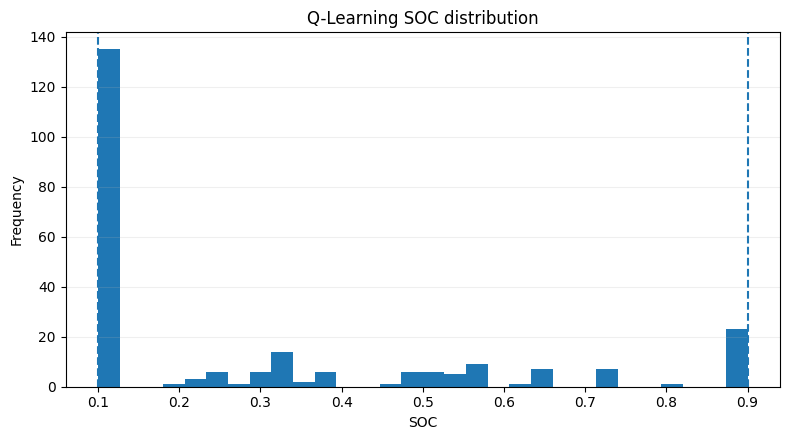

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(logs.soc, bins=30)
ax.axvline(cfg["battery"]["min_soc"], linestyle="--"); ax.axvline(cfg["battery"]["max_soc"], linestyle="--")
ax.set_title("Q-Learning SOC distribution")
ax.set_xlabel("SOC"); ax.set_ylabel("Frequency"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb09_01_soc_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

## 2. Action distribution

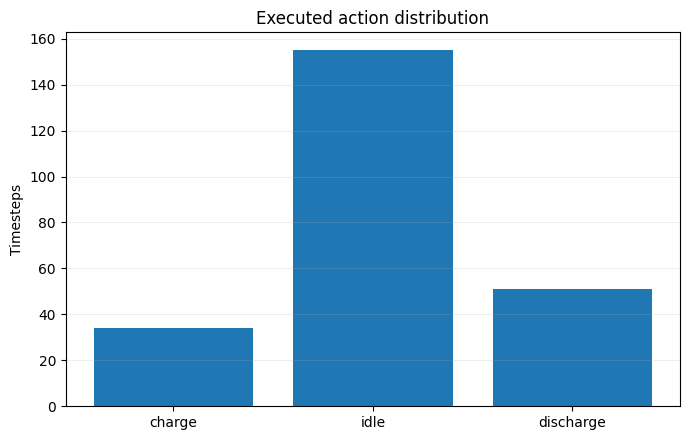

In [4]:
p = logs.executed_battery_power_kw
action_label = np.where(p > 1e-6, "charge", np.where(p < -1e-6, "discharge", "idle"))
action_counts = pd.Series(action_label).value_counts().reindex(["charge","idle","discharge"], fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(action_counts.index, action_counts.values)
ax.set_title("Executed action distribution")
ax.set_ylabel("Timesteps"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb09_02_action_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

## 3. Milyen árakon választja az egyes actionöket?

/tmp/ipykernel_1187/1411437076.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=["charge","idle","discharge"], showfliers=False)


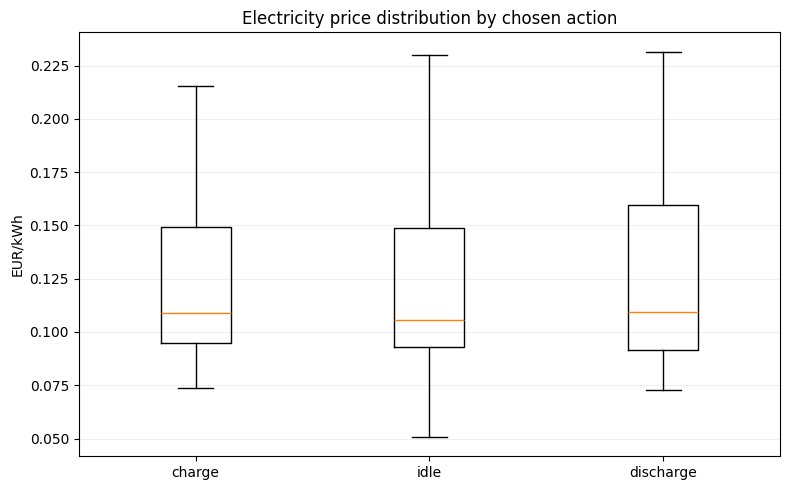

In [5]:
tmp = logs.copy(); tmp["action_label"] = action_label
groups = [tmp.loc[tmp.action_label == a, "price"].values for a in ["charge","idle","discharge"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(groups, labels=["charge","idle","discharge"], showfliers=False)
ax.set_title("Electricity price distribution by chosen action")
ax.set_ylabel("EUR/kWh"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb09_03_price_by_action.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. SOC × price scatter, actionnel jelölve

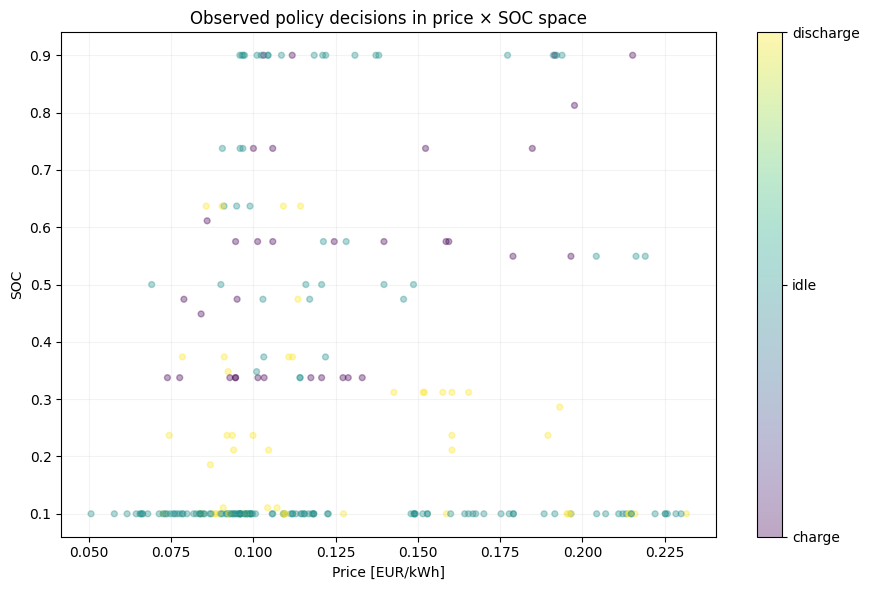

In [6]:
mapping = {"charge":0, "idle":1, "discharge":2}
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(tmp.price, tmp.soc, c=tmp.action_label.map(mapping), alpha=0.35, s=18, vmin=0, vmax=2)
ax.set_title("Observed policy decisions in price × SOC space")
ax.set_xlabel("Price [EUR/kWh]"); ax.set_ylabel("SOC"); ax.grid(alpha=0.15)
cbar = fig.colorbar(sc, ax=ax, ticks=[0,1,2]); cbar.ax.set_yticklabels(["charge","idle","discharge"])
fig.tight_layout(); fig.savefig(FIG_DIR / "nb09_04_price_soc_actions.png", dpi=170, bbox_inches="tight")
plt.show()

## 5. Learned policy heatmap kontrollált state-szelettel

Az előző scatter csak a ténylegesen látott test transitionöket mutatja. A heatmap ezzel szemben mesterségesen végigkérdez egy price × SOC rácsot fix tipikus demand/renewable/hour mellett.

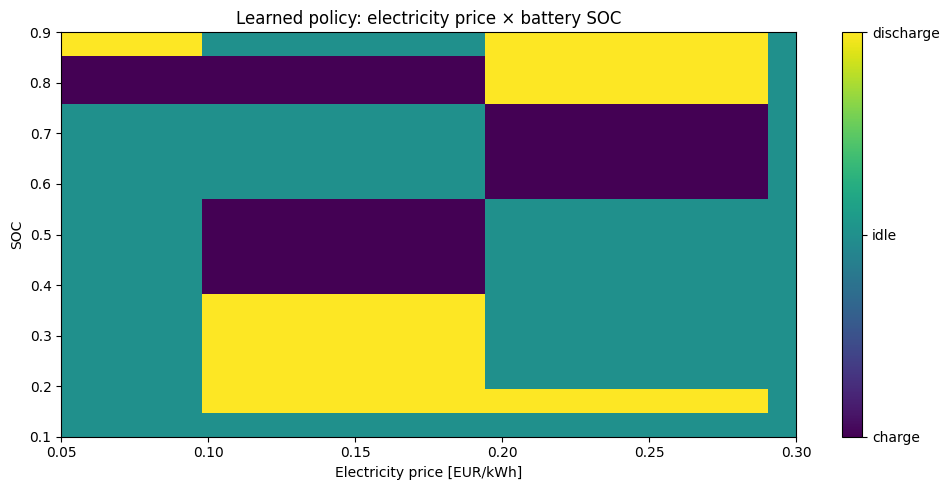

In [7]:
env = build_env(test, cfg, random_start=False)
socs = np.linspace(0.1, 0.9, 17); prices = np.linspace(0.05, 0.30, 26)
mat = np.zeros((len(socs), len(prices)), dtype=int)
for i, soc in enumerate(socs):
    for j, price in enumerate(prices):
        raw = np.array([soc, price, 0.55*env._demand_max, 0.15*env._renewable_max, 18], dtype=np.float32)
        scale = np.array([1.0, env._price_max, env._demand_max, env._renewable_max, 23.0], dtype=np.float32)
        state = agent.discretizer.transform(raw/scale)
        q = agent._values(state)
        valid = [1] + ([0] if soc < env.spec.max_soc-1e-8 else []) + ([2] if soc > env.spec.min_soc+1e-8 else [])
        mat[i,j] = max(valid, key=lambda a: q[a])
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(mat, aspect="auto", origin="lower", extent=[prices.min(), prices.max(), socs.min(), socs.max()], vmin=0, vmax=2)
ax.set_title("Learned policy: electricity price × battery SOC")
ax.set_xlabel("Electricity price [EUR/kWh]"); ax.set_ylabel("SOC")
cbar = fig.colorbar(im, ax=ax, ticks=[0,1,2]); cbar.ax.set_yticklabels(["charge","idle","discharge"])
fig.tight_layout(); fig.savefig(FIG_DIR / "nb09_05_policy_heatmap.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Action transition matrix

Ez megmutatja, hogy az agent mennyire „kapkod”: például gyakran vált-e közvetlenül charge-ról discharge-ra. Egy valódi controllerben az ilyen switching viselkedés további penaltyt vagy minimum dwell-time constraintet is indokolhat.

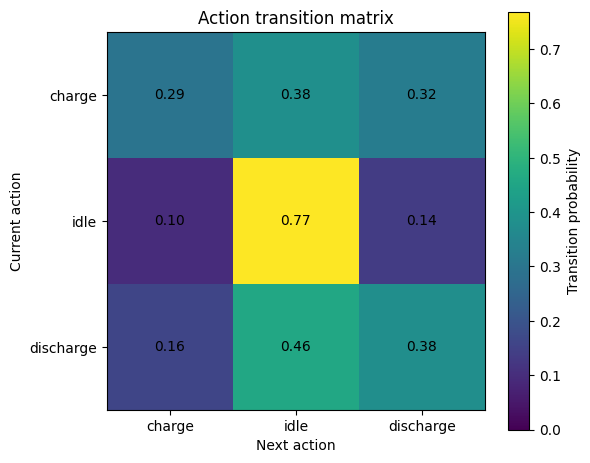

In [8]:
labels = ["charge","idle","discharge"]
seq = pd.Series(action_label)
trans = pd.crosstab(seq.iloc[:-1].to_numpy(), seq.iloc[1:].to_numpy(), normalize="index").reindex(index=labels, columns=labels, fill_value=0)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(trans.values, vmin=0, vmax=max(0.01, trans.values.max()))
ax.set_xticks(range(3), labels); ax.set_yticks(range(3), labels)
for i in range(3):
    for j in range(3): ax.text(j,i,f"{trans.iloc[i,j]:.2f}",ha="center",va="center")
fig.colorbar(im, ax=ax, label="Transition probability")
ax.set_title("Action transition matrix")
ax.set_xlabel("Next action"); ax.set_ylabel("Current action")
fig.tight_layout(); fig.savefig(FIG_DIR / "nb09_06_action_transition_matrix.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Requested vs executed mismatch rate

In [9]:
mismatch_rate = 100 * logs.constraint_violation.mean()
print(f"Constraint/mismatch event rate: {mismatch_rate:.2f}%")
viol = logs.loc[logs.constraint_violation > 0, ["soc_before","soc","requested_battery_power_kw","executed_battery_power_kw","price"]]
display(viol.head(12))

Constraint/mismatch event rate: 10.42%


,soc_before,soc,requested_battery_power_kw,executed_battery_power_kw,price
2,0.737500,0.9,30.0,20.526316,0.103131
9,0.110526,0.1,-30.0,-1.200000,0.084290
17,0.311842,0.1,-30.0,-24.150000,0.231616
28,0.236842,0.1,-30.0,-15.600000,0.196587
41,0.337500,0.1,-30.0,-27.075000,0.096267
49,0.737500,0.9,30.0,20.526316,0.215258
64,0.110526,0.1,-30.0,-1.200000,0.083835
73,0.236842,0.1,-30.0,-15.600000,0.088613
84,0.812500,0.9,30.0,11.052632,0.191590
95,0.348026,0.1,-30.0,-28.275000,0.072624


## 8. Policy lookup table néhány kézzel választott state-re

In [10]:
examples = []
for soc in [0.2, 0.5, 0.8]:
    for price in [0.07, 0.15, 0.25]:
        raw = np.array([soc, price, 0.55*env._demand_max, 0.15*env._renewable_max, 18], dtype=np.float32)
        scale = np.array([1.0, env._price_max, env._demand_max, env._renewable_max, 23.0], dtype=np.float32)
        state = agent.discretizer.transform(raw/scale)
        q = agent._values(state)
        valid = [1] + ([0] if soc < env.spec.max_soc-1e-8 else []) + ([2] if soc > env.spec.min_soc+1e-8 else [])
        action = max(valid, key=lambda a:q[a])
        examples.append({"SOC":soc,"price":price,"Q_charge":q[0],"Q_idle":q[1],"Q_discharge":q[2],"chosen_action":["charge","idle","discharge"][action]})
display(pd.DataFrame(examples))

,SOC,price,Q_charge,Q_idle,Q_discharge,chosen_action
0,0.2,0.07,0.000000,0.000000,0.000000,idle
1,0.2,0.15,-26.752421,-28.567038,-25.639885,discharge
2,0.2,0.25,-25.567818,-23.867007,-24.303309,idle
3,0.5,0.07,0.000000,0.000000,0.000000,idle
4,0.5,0.15,-17.547919,-17.738117,-18.031546,charge
5,0.5,0.25,-15.080553,-14.290498,-19.300415,idle
6,0.8,0.07,0.000000,-0.630788,0.000000,charge
7,0.8,0.15,-8.973432,-9.382951,-10.367646,charge
8,0.8,0.25,-4.833183,-7.860484,-4.594557,discharge


## 9. Custom environment → CityLearn útvonal

A projekt tudatosan nem CityLearnnel kezdődik. A saját environmentben minden fogalom átlátható; ezután lehet standardizált, realisztikusabb benchmarkra váltani.

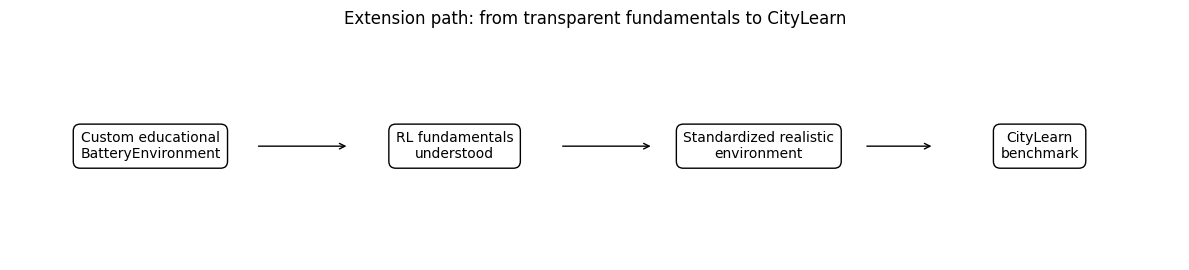

In [11]:
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")
labels = [
    "Custom educational\nBatteryEnvironment",
    "RL fundamentals\nunderstood",
    "Standardized realistic\nenvironment",
    "CityLearn\nbenchmark",
]
xs = [0.12, 0.38, 0.64, 0.88]
for x, label in zip(xs, labels):
    ax.text(x, 0.5, label, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black"))
for a, b in zip(xs[:-1], xs[1:]):
    ax.annotate("", xy=(b-0.09, 0.5), xytext=(a+0.09, 0.5), arrowprops=dict(arrowstyle="->"))
ax.set_title("Extension path: from transparent fundamentals to CityLearn")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb09_07_citylearn_path.png", dpi=170, bbox_inches="tight")
plt.show()

# Final engineering takeaway

A projekt üzenete nem az, hogy „lefuttattunk egy RL algoritmust”. A teljes gondolkodási lánc:

**energy data → physically constrained environment → reward design → baseline controllers → Q-Learning → DQN/PPO → train/validation/test evaluation → multiple seeds → stress tests → ablation → policy interpretation.**

Ez az a szint, amely már jól demonstrálja, hogy a reinforcement learninget nem játékkörnyezetként, hanem mérnöki döntési rendszerként kezeled.